# EE 446 TinyML — Model Pruning with Quantization  
## Student TODO Version: Pruning and Quantization of a DNN Using the UCI Human Activity Recognition Dataset

### Overview
In this notebook, you will:
- train a baseline DNN on the **UCI HAR** dataset,
- apply **magnitude-based pruning**,
- compare the pruned model before and after `strip_pruning(...)`, and
- combine pruning with **float16 quantization**.

Use the **`Python (tinyml-arduino)`** Jupyter kernel for this notebook.


## 1. Environment Setup

This notebook is designed to run with the **`Python (tinyml-arduino)`** Jupyter kernel that you already created.

This notebook assumes the environment already contains:
- `tensorflow==2.14.1`
- `tensorflow-model-optimization==0.8.0`
- `numpy`, `pandas`, `matplotlib`, and `scikit-learn`

Do **not** reinstall TensorFlow packages inside the notebook if you are already using the working TinyML environment.


In [2]:
import os
import math
import zipfile
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python executable:", os.sys.executable)
print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


2026-04-23 22:14:31.013255: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-23 22:14:31.280082: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-23 22:14:31.280126: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-23 22:14:31.282207: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-23 22:14:31.429504: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-23 22:14:31.431232: I tensorflow/core/platform/cpu_feature_guard.cc:182] This Tens

Python executable: /home/thomas/ai/projects/tinyml-arduino/bin/python
TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 2. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals,
- **6 activity classes**, and
- predefined **training** and **test** splits.

The code below downloads and extracts the dataset if it is not already present in the working directory.


In [3]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    urllib.request.urlretrieve(dataset_url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 3. Load the Data

In [5]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt as float32
    # 2. Load y_train from train/y_train.txt as int32
    # 3. Load X_test from test/X_test.txt as float32
    # 4. Load y_test from test/y_test.txt as int32
    # 5. Convert labels to zero-based class indices by subtracting 1

    # <-- Enter your code here <--#
    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"), dtype=np.float32)
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt"), dtype=np.int32)

    X_test  = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt"), dtype=np.float32)
    y_test  = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt"), dtype=np.int32)

    # zero-based labels
    y_train -= 1
    y_test  -= 1

    return X_train, y_train, X_test, y_test


X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO:
# Define num_features and num_classes.
# Print the train/test shapes and the number of features/classes.

# <-- Enter your code here <--#
num_features = X_train.shape[1]
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("num_features:", num_features)
print("num_classes:", num_classes)

X_train shape: (7352, 561)
y_train shape: (7352,)
X_test shape: (2947, 561)
y_test shape: (2947,)
num_features: 561
num_classes: 6


## 4. Quick Inspection

In [6]:
# TODO:
# Create a small summary table showing:
# - class index,
# - class name, and
# - number of training samples in each class.

# <-- Enter your code here <--#
rows = []

for i, name in enumerate(class_names):
    count = np.sum(y_train == i)

    rows.append({
        "Class Index": i,
        "Class Name": name,
        "Train Samples": count
    })

summary_df = pd.DataFrame(rows)
summary_df

,Class Index,Class Name,Train Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 5. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [7]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    # <-- Enter your code here <--#
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


2026-04-28 16:00:32.583488: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-28 16:00:32.589255: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model

In [8]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#
baseline_history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/40
92/92 [==============================] - -1s 6ms/step - loss: 0.4946 - accuracy: 0.7973 - val_loss: 0.2007 - val_accuracy: 0.9286
Epoch 2/40
92/92 [==============================] - 0s 5ms/step - loss: 0.1644 - accuracy: 0.9345 - val_loss: 0.1620 - val_accuracy: 0.9279
Epoch 3/40
92/92 [==============================] - 1s 6ms/step - loss: 0.1244 - accuracy: 0.9515 - val_loss: 0.1836 - val_accuracy: 0.9293
Epoch 4/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0973 - accuracy: 0.9600 - val_loss: 0.1474 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 0s 5ms/step - loss: 0.0841 - accuracy: 0.9655 - val_loss: 0.2343 - val_accuracy: 0.9171
Epoch 6/40
92/92 [==============================] - 0s 5ms/step - loss: 0.0692 - accuracy: 0.9719 - val_loss: 0.2733 - val_accuracy: 0.9191
Epoch 7/40
92/92 [==============================] - 0s 5ms/step - loss: 0.0535 - accuracy: 0.9799 - val_loss: 0.1660 - val_accuracy: 0.9388
Epoch 8/40
92/92 [=

### Training Curves

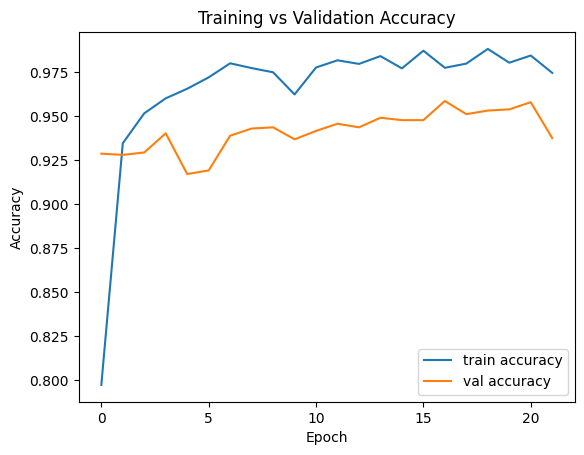

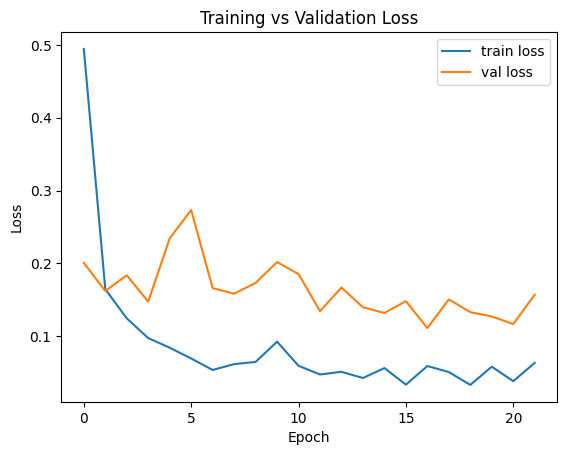

In [9]:
# TODO:
# Plot:
# 1. training accuracy vs validation accuracy
# 2. training loss vs validation loss

# <-- Enter your code here <--#
# Accuracy
plt.figure()
plt.plot(baseline_history.history["accuracy"], label="train accuracy")
plt.plot(baseline_history.history["val_accuracy"], label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

# Loss
plt.figure()
plt.plot(baseline_history.history["loss"], label="train loss")
plt.plot(baseline_history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# Chatgpt helped with this again because im lazy

## 6. Evaluate the Baseline Keras Model

93/93 [==============================] - 0s 1ms/step
Test Accuracy: 0.9450288428910757

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.98      0.95      0.96       496
  WALKING_UPSTAIRS       0.93      0.95      0.94       471
WALKING_DOWNSTAIRS       0.92      0.94      0.93       420
           SITTING       0.92      0.90      0.91       491
          STANDING       0.92      0.92      0.92       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.95      2947
         macro avg       0.94      0.94      0.94      2947
      weighted avg       0.95      0.95      0.95      2947



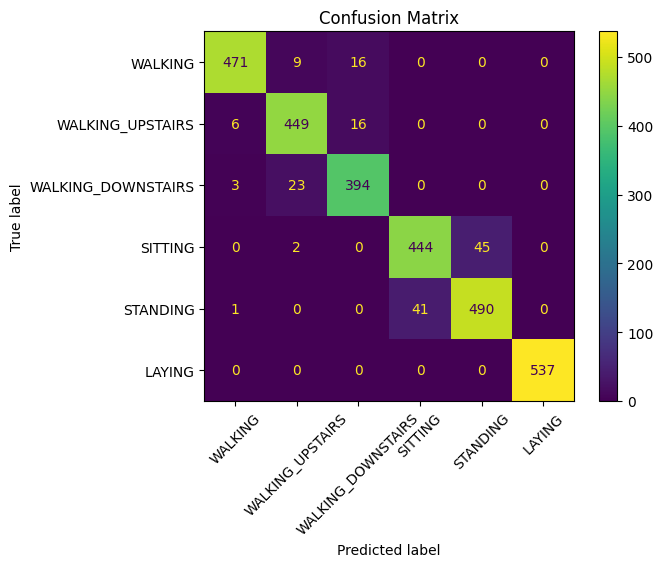

In [11]:
# TODO:
# 1. Predict class probabilities on X_test
# 2. Convert probabilities to class labels using argmax
# 3. Compute the test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

# <-- Enter your code here <--#
# 1.
y_probs = baseline_model.predict(X_test)

# 2.
y_pred = np.argmax(y_probs, axis=1)

# 3.
test_acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_acc)

# 4.
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# 5.
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot()
plt.xticks(rotation=45)
plt.title("Confusion Matrix")
plt.show()

# Part I: Model Pruning with Sparsity

In this part, we apply **magnitude-based pruning** to the DNN. The key idea is to gradually set small-magnitude weights to zero during training.

We will compare:
1. the baseline TensorFlow Lite model,
2. the pruned model converted **without** stripping the pruning wrappers, and
3. the stripped sparse model converted with **experimental sparsity-aware optimization**.


## 7. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model size.


In [12]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the TFLite input tensor expects int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        # <-- Enter your code here <--#
        if input_details["dtype"] in [np.int8, np.uint8]:
            x = x / input_scale + input_zero_point
            x = np.round(x).astype(input_details["dtype"])
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # Dequantize the output only when the output tensor is int8 or uint8.

        # <-- Enter your code here <--# 
        if output_details["dtype"] in [np.int8, np.uint8]:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    # TODO:
    # Create a TFLiteConverter from the Keras model and return the converted FP32 model bytes.

    # <-- Enter your code here <--#
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()


## 8. Convert the Baseline Model to TensorFlow Lite

In [13]:
# TODO:
# Convert the baseline model to FP32 TensorFlow Lite.
# Save the .tflite file, compute its size in KB, and evaluate it on X_test.

# <-- Enter your code here <--#
baseline_tflite = convert_to_tflite_fp32(baseline_model)

baseline_size_kb = save_binary_model(
    baseline_tflite,
    "baseline_fp32.tflite"
)

baseline_tflite_acc, baseline_tflite_pred = evaluate_tflite_model(
    baseline_tflite,
    X_test,
    y_test
)

print("Baseline FP32 TFLite Size (KB):", baseline_size_kb)
print("Baseline FP32 TFLite Accuracy:", baseline_tflite_acc)

INFO:tensorflow:Assets written to: /tmp/tmp12jzleab/assets


INFO:tensorflow:Assets written to: /tmp/tmp12jzleab/assets


Baseline FP32 TFLite Size (KB): 726.71875
Baseline FP32 TFLite Accuracy: 0.9450288428910757


2026-04-28 16:05:52.723252: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-28 16:05:52.723968: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-28 16:05:52.732475: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp12jzleab
2026-04-28 16:05:52.735869: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-28 16:05:52.735906: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp12jzleab
2026-04-28 16:05:52.768093: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-04-28 16:05:52.770226: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-28 16:05:52.847512: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp12jzleab
2026-04

## 9. Apply Magnitude-Based Pruning

We will prune the DNN using a **polynomial decay schedule**:
- start from low sparsity,
- gradually increase sparsity during training, and
- finish with a highly sparse model.

After training, we will compare:
- the pruned model **with** the pruning wrappers still present, and
- the final sparse model after applying `strip_pruning(...)`.


In [14]:
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

pruning_epochs = 12
batch_size = 64

# TODO:
# Compute steps_per_epoch using 80% of the training set and the selected batch size.
# Define pruning_params using PolynomialDecay with:
# - initial_sparsity=0.20
# - final_sparsity=0.85
# - begin_step=0
# - end_step=steps_per_epoch * pruning_epochs

# <-- Enter your code here <--#
train_samples = int(len(X_train) * 0.8)
steps_per_epoch = math.ceil(train_samples / batch_size)

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs
    )
}


# TODO:
# Create the pruned model by wrapping a fresh baseline DNN with prune_low_magnitude.
# Compile it with Adam(1e-3), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#
pruned_model = prune_low_magnitude(
    build_baseline_model(num_features, num_classes),
    **pruning_params
)

pruned_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the pruned model using:
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks

# <-- Enter your code here <--#
pruned_history = pruned_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks
)
#Chatgpt helped with this a bit as well

Epoch 1/12
92/92 [==============================] - 2s 7ms/step - loss: 0.4867 - accuracy: 0.8123 - val_loss: 0.2203 - val_accuracy: 0.9211
Epoch 2/12
92/92 [==============================] - 0s 5ms/step - loss: 0.1696 - accuracy: 0.9345 - val_loss: 0.2536 - val_accuracy: 0.8980
Epoch 3/12
92/92 [==============================] - 0s 5ms/step - loss: 0.1201 - accuracy: 0.9565 - val_loss: 0.1842 - val_accuracy: 0.9307
Epoch 4/12
92/92 [==============================] - 0s 5ms/step - loss: 0.1130 - accuracy: 0.9616 - val_loss: 0.1342 - val_accuracy: 0.9429
Epoch 5/12
92/92 [==============================] - 0s 5ms/step - loss: 0.0967 - accuracy: 0.9662 - val_loss: 0.1205 - val_accuracy: 0.9477
Epoch 6/12
92/92 [==============================] - 0s 5ms/step - loss: 0.1321 - accuracy: 0.9587 - val_loss: 0.1870 - val_accuracy: 0.9313
Epoch 7/12
92/92 [==============================] - 0s 5ms/step - loss: 0.1763 - accuracy: 0.9437 - val_loss: 0.1830 - val_accuracy: 0.9341
Epoch 8/12
92/92 [==

## 10. Convert the Pruned Model Before and After Stripping the Pruning Wrappers

First, we convert the pruned model **with** the pruning wrappers still attached.

Next, we strip the pruning wrappers and convert the resulting sparse model with:
- `tf.lite.Optimize.EXPERIMENTAL_SPARSITY`

This is the proper way to preserve sparsity in the exported TensorFlow Lite model.


In [16]:
# TODO:
# 1. Convert the pruned model WITH the pruning wrappers still attached to FP32 TensorFlow Lite.
# 2. Save the model and evaluate it on X_test.
# 3. Strip the pruning wrappers using strip_pruning(...).
# 4. Convert the stripped model with tf.lite.Optimize.EXPERIMENTAL_SPARSITY.
# 5. Save the stripped sparse model and evaluate it on X_test.

# <-- Enter your code here <--#

# Chatgpt assisted with this after errors

pruned_tflite = convert_to_tflite_fp32(pruned_model)

pruned_size_kb = save_binary_model(
    pruned_tflite,
    "pruned_wrapped_fp32.tflite"
)

pruned_acc, pruned_pred = evaluate_tflite_model(
    pruned_tflite,
    X_test,
    y_test
)

# 3
stripped_model = strip_pruning(pruned_model)

# 4
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]

stripped_sparse_tflite = converter.convert()

# 5
stripped_sparse_size_kb = save_binary_model(
    stripped_sparse_tflite,
    "pruned_stripped_sparse.tflite"
)

stripped_sparse_acc, stripped_sparse_pred = evaluate_tflite_model(
    stripped_sparse_tflite,
    X_test,
    y_test
)

print("Pruned Wrapped Size (KB):", pruned_size_kb)
print("Pruned Wrapped Accuracy:", pruned_acc)

print("Stripped Sparse Size (KB):", stripped_sparse_size_kb)
print("Stripped Sparse Accuracy:", stripped_sparse_acc)

INFO:tensorflow:Assets written to: /tmp/tmp8gzx3h5d/assets


INFO:tensorflow:Assets written to: /tmp/tmp8gzx3h5d/assets
2026-04-28 16:08:23.261538: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-28 16:08:23.261589: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-28 16:08:23.261766: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp8gzx3h5d
2026-04-28 16:08:23.266258: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-28 16:08:23.266278: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp8gzx3h5d
2026-04-28 16:08:23.280476: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-28 16:08:23.333884: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp8gzx3h5d
2026-04-28 16:08:23.348707: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpqpyl890v/assets


INFO:tensorflow:Assets written to: /tmp/tmpqpyl890v/assets
2026-04-28 16:08:24.289131: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-28 16:08:24.289200: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.


Pruned Wrapped Size (KB): 1454.17578125
Pruned Wrapped Accuracy: 0.9277231082456736
Stripped Sparse Size (KB): 338.8515625
Stripped Sparse Accuracy: 0.9277231082456736


2026-04-28 16:08:24.289378: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpqpyl890v
2026-04-28 16:08:24.290220: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-28 16:08:24.290233: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpqpyl890v
2026-04-28 16:08:24.291861: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-28 16:08:24.310177: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpqpyl890v
2026-04-28 16:08:24.316139: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 26754 microseconds.


## 11. Part I Comparison: Accuracy and Model Size

In [17]:
# TODO:
# Create a comparison DataFrame for Part I with the columns:
# Model, Format, Test Accuracy, Model Size (KB)

# Include:
# - baseline FP32 TFLite
# - pruned FP32 TFLite with mask
# - stripped sparse FP32 TFLite

# <-- Enter your code here <--#
part1_df = pd.DataFrame([
    {
        "Model": "Baseline",
        "Format": "FP32 TFLite",
        "Test Accuracy": baseline_tflite_acc,
        "Model Size (KB)": baseline_size_kb
    },
    {
        "Model": "Pruned (with mask)",
        "Format": "FP32 TFLite",
        "Test Accuracy": pruned_acc,
        "Model Size (KB)": pruned_size_kb
    },
    {
        "Model": "Pruned (stripped sparse)",
        "Format": "Sparse FP32 TFLite",
        "Test Accuracy": stripped_sparse_acc,
        "Model Size (KB)": stripped_sparse_size_kb
    }
])

part1_df

,Model,Format,Test Accuracy,Model Size (KB)
0,Baseline,FP32 TFLite,0.945029,726.718750
1,Pruned (with mask),FP32 TFLite,0.927723,1454.175781
2,Pruned (stripped sparse),Sparse FP32 TFLite,0.927723,338.851562


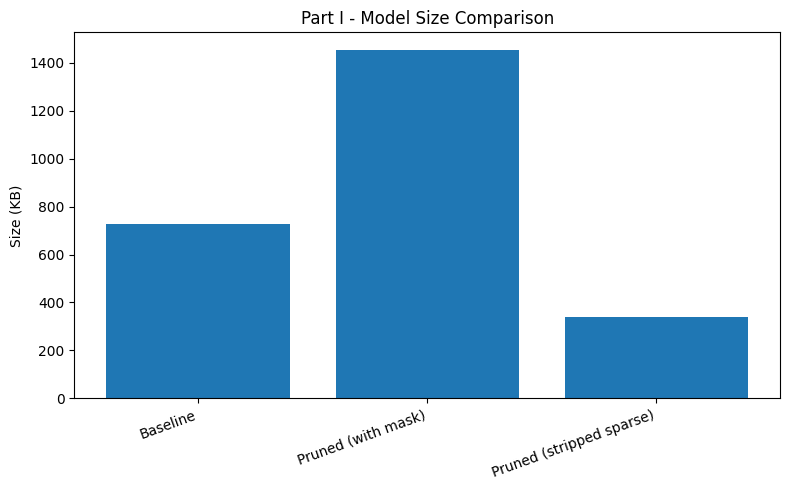

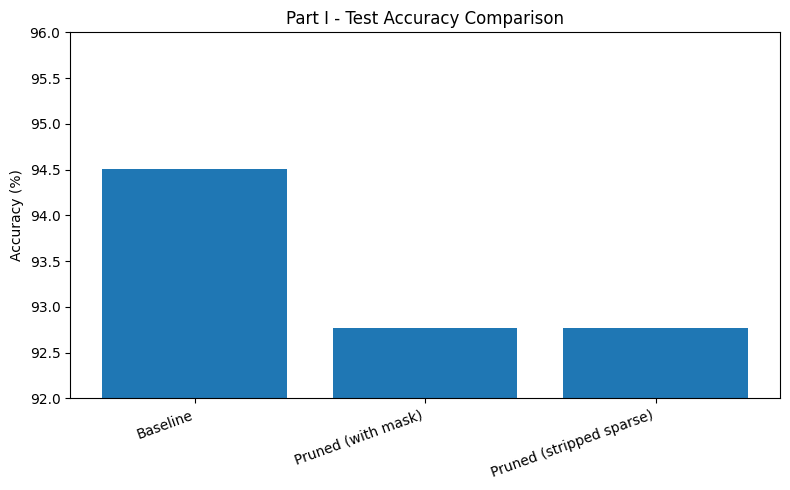

In [25]:
# TODO:
# Plot:
# 1. a bar chart of the Part I model sizes
# 2. a bar chart of the Part I test accuracies

# <-- Enter your code here <--#
# Model sizes
plt.figure(figsize=(8, 5))
plt.bar(part1_df["Model"], part1_df["Model Size (KB)"])
plt.ylabel("Size (KB)")
plt.title("Part I - Model Size Comparison")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# Test accuracies
plt.figure(figsize=(8, 5))
plt.bar(part1_df["Model"], part1_df["Test Accuracy"] * 100)
plt.ylabel("Accuracy (%)")
plt.ylim(92, 96)
plt.title("Part I - Test Accuracy Comparison")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### Confusion Matrix for the Stripped Sparse Model

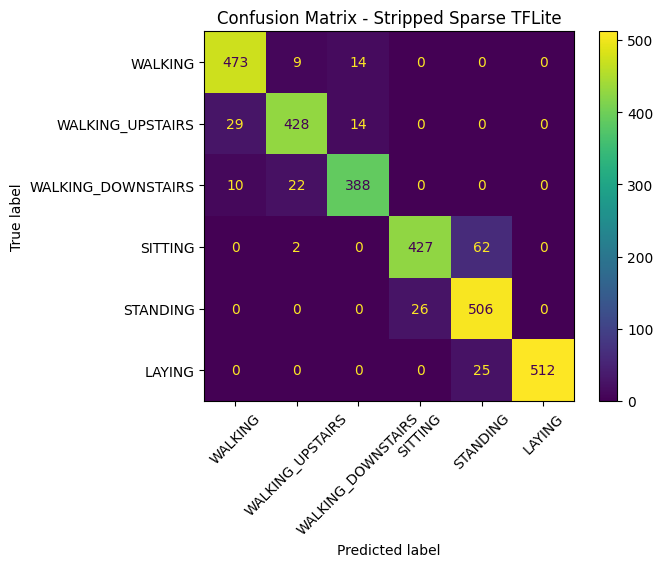

Classification Report:

                    precision    recall  f1-score   support

           WALKING       0.92      0.95      0.94       496
  WALKING_UPSTAIRS       0.93      0.91      0.92       471
WALKING_DOWNSTAIRS       0.93      0.92      0.93       420
           SITTING       0.94      0.87      0.90       491
          STANDING       0.85      0.95      0.90       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.93      2947
         macro avg       0.93      0.93      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



In [19]:
# TODO:
# Plot the confusion matrix for the stripped sparse TFLite model.
# Print the classification report for the stripped sparse TFLite model.

# <-- Enter your code here <--#
cm = confusion_matrix(y_test, stripped_sparse_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot()
plt.xticks(rotation=45)
plt.title("Confusion Matrix - Stripped Sparse TFLite")
plt.show()

print("Classification Report:\n")
print(
    classification_report(
        y_test,
        stripped_sparse_pred,
        target_names=class_names
    )
)

# Part II: Model Pruning + Float16 Quantization

In this part, we combine **pruning** and **float16 quantization**.

We will compare:
1. the pruned TensorFlow Lite model **with** the pruning wrappers still attached, after float16 quantization, and
2. the stripped sparse TensorFlow Lite model after **both** sparsity-aware optimization and float16 quantization.

This lets us observe whether properly finalizing the pruned model leads to a more compact deployable representation.


In [20]:
# TODO:
# Part II: combine pruning and float16 quantization.
#
# 1. Convert the pruned model with mask using:
#    - optimizations = [tf.lite.Optimize.DEFAULT]
#    - supported_types = [tf.float16]
# 2. Save and evaluate the float16 model with mask.
# 3. Convert the stripped sparse model using:
#    - optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
#    - supported_types = [tf.float16]
# 4. Save and evaluate the stripped sparse + float16 model.

# <-- Enter your code here <--#
# chat also helped with some errors here
converter = tf.lite.TFLiteConverter.from_keras_model(pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

pruned_f16_tflite = converter.convert()

pruned_f16_size_kb = save_binary_model(
    pruned_f16_tflite,
    "pruned_mask_float16.tflite"
)

pruned_f16_acc, pruned_f16_pred = evaluate_tflite_model(
    pruned_f16_tflite,
    X_test,
    y_test
)

# 3 and 4
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter.optimizations = [
    tf.lite.Optimize.DEFAULT,
    tf.lite.Optimize.EXPERIMENTAL_SPARSITY
]
converter.target_spec.supported_types = [tf.float16]

stripped_sparse_f16_tflite = converter.convert()

stripped_sparse_f16_size_kb = save_binary_model(
    stripped_sparse_f16_tflite,
    "stripped_sparse_float16.tflite"
)

stripped_sparse_f16_acc, stripped_sparse_f16_pred = evaluate_tflite_model(
    stripped_sparse_f16_tflite,
    X_test,
    y_test
)

print("Pruned + Float16 Size (KB):", pruned_f16_size_kb)
print("Pruned + Float16 Accuracy:", pruned_f16_acc)

print("Sparse + Float16 Size (KB):", stripped_sparse_f16_size_kb)
print("Sparse + Float16 Accuracy:", stripped_sparse_f16_acc)

INFO:tensorflow:Assets written to: /tmp/tmp1u5nyltu/assets


INFO:tensorflow:Assets written to: /tmp/tmp1u5nyltu/assets
2026-04-28 16:09:51.305626: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-28 16:09:51.305684: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-28 16:09:51.305875: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp1u5nyltu
2026-04-28 16:09:51.310501: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-28 16:09:51.310530: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp1u5nyltu
2026-04-28 16:09:51.323918: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-28 16:09:51.373084: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp1u5nyltu
2026-04-28 16:09:51.387267: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmp1oc7mhsl/assets


INFO:tensorflow:Assets written to: /tmp/tmp1oc7mhsl/assets
2026-04-28 16:09:52.234572: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-28 16:09:52.234667: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.


Pruned + Float16 Size (KB): 732.5859375
Pruned + Float16 Accuracy: 0.9277231082456736
Sparse + Float16 Size (KB): 223.7109375
Sparse + Float16 Accuracy: 0.9277231082456736


2026-04-28 16:09:52.234855: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp1oc7mhsl
2026-04-28 16:09:52.235501: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-28 16:09:52.235523: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp1oc7mhsl
2026-04-28 16:09:52.237637: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-28 16:09:52.255778: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp1oc7mhsl
2026-04-28 16:09:52.261174: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 26316 microseconds.


## 12. Part II Comparison: Accuracy and Model Size

In [21]:
# TODO:
# Create a Part II comparison DataFrame with the columns:
# Model, Format, Test Accuracy, Model Size (KB)
#
# Include:
# - pruned FP32 with mask
# - stripped sparse FP32
# - pruned float16 with mask
# - stripped sparse float16

# <-- Enter your code here <--#
part2_df = pd.DataFrame([
    {
        "Model": "Pruned (with mask)",
        "Format": "FP32 TFLite",
        "Test Accuracy": pruned_acc,
        "Model Size (KB)": pruned_size_kb
    },
    {
        "Model": "Pruned (stripped sparse)",
        "Format": "Sparse FP32 TFLite",
        "Test Accuracy": stripped_sparse_acc,
        "Model Size (KB)": stripped_sparse_size_kb
    },
    {
        "Model": "Pruned (with mask)",
        "Format": "Float16 TFLite",
        "Test Accuracy": pruned_f16_acc,
        "Model Size (KB)": pruned_f16_size_kb
    },
    {
        "Model": "Pruned (stripped sparse)",
        "Format": "Sparse Float16 TFLite",
        "Test Accuracy": stripped_sparse_f16_acc,
        "Model Size (KB)": stripped_sparse_f16_size_kb
    }
])

part2_df

,Model,Format,Test Accuracy,Model Size (KB)
0,Pruned (with mask),FP32 TFLite,0.927723,1454.175781
1,Pruned (stripped sparse),Sparse FP32 TFLite,0.927723,338.851562
2,Pruned (with mask),Float16 TFLite,0.927723,732.585938
3,Pruned (stripped sparse),Sparse Float16 TFLite,0.927723,223.710938


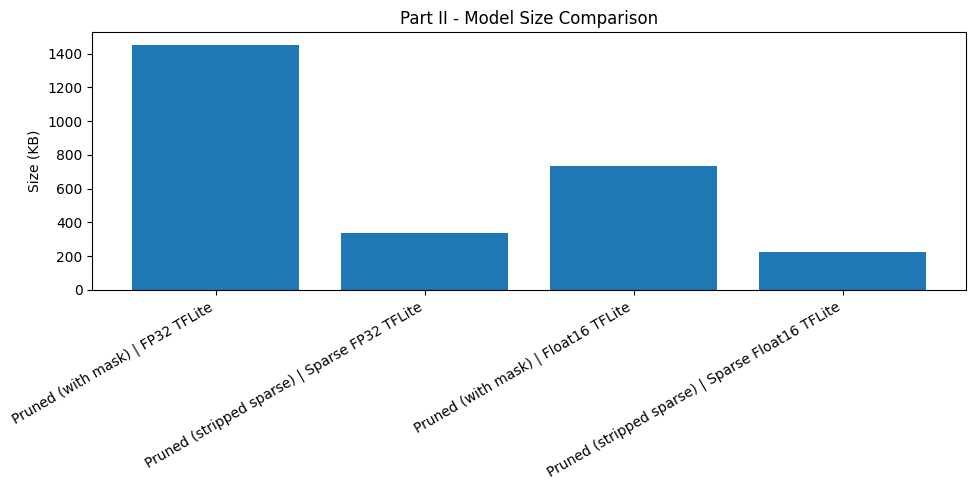

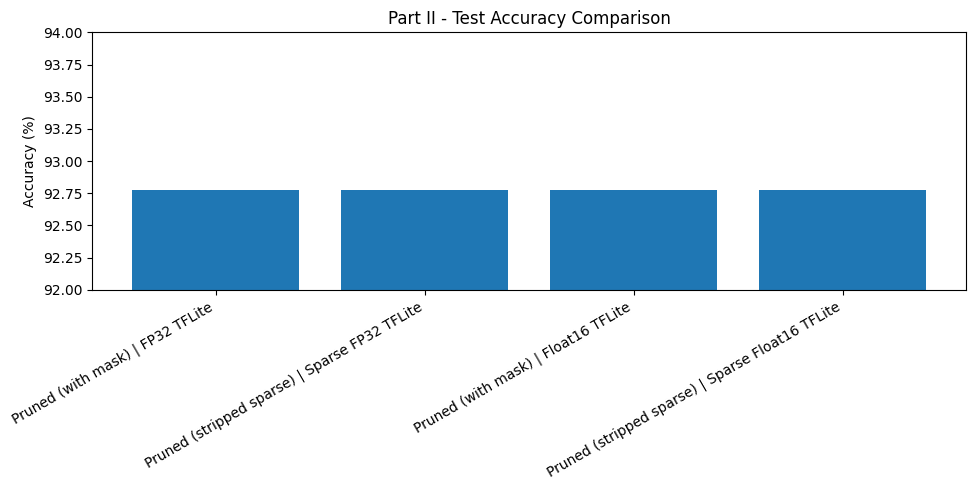

In [24]:
# TODO:
# Plot:
# 1. a bar chart of Part II model sizes
# 2. a bar chart of Part II test accuracies

# <-- Enter your code here <--#
labels = part2_df["Model"] + " | " + part2_df["Format"]

# Model sizes
plt.figure(figsize=(10, 5))
plt.bar(labels, part2_df["Model Size (KB)"])
plt.ylabel("Size (KB)")
plt.title("Part II - Model Size Comparison")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Test accuracies
plt.figure(figsize=(10, 5))
plt.bar(labels, part2_df["Test Accuracy"] * 100)
plt.ylabel("Accuracy (%)")
plt.ylim(92, 94)
plt.title("Part II - Test Accuracy Comparison")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Confusion Matrix for the Stripped Sparse + Float16 Model

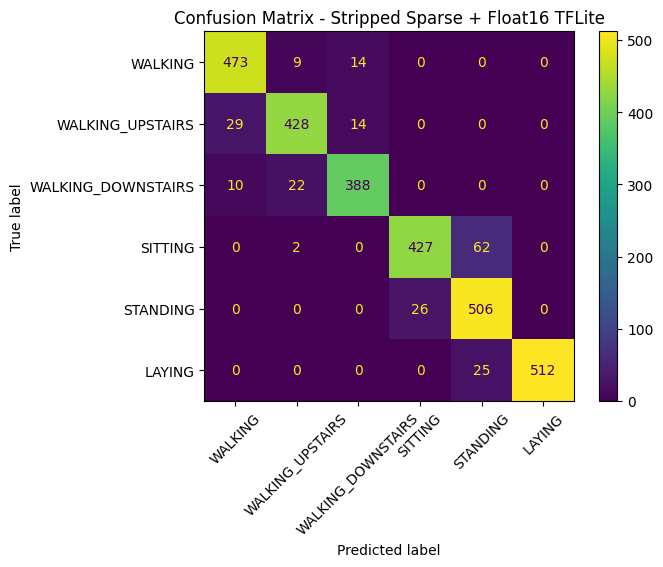

Classification Report:

                    precision    recall  f1-score   support

           WALKING       0.92      0.95      0.94       496
  WALKING_UPSTAIRS       0.93      0.91      0.92       471
WALKING_DOWNSTAIRS       0.93      0.92      0.93       420
           SITTING       0.94      0.87      0.90       491
          STANDING       0.85      0.95      0.90       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.93      2947
         macro avg       0.93      0.93      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



In [23]:
# TODO:
# Plot the confusion matrix for the stripped sparse + float16 TFLite model.
# Print the classification report for the stripped sparse + float16 TFLite model.

# <-- Enter your code here <--#

cm = confusion_matrix(y_test, stripped_sparse_f16_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot()
plt.xticks(rotation=45)
plt.title("Confusion Matrix - Stripped Sparse + Float16 TFLite")
plt.show()

print("Classification Report:\n")
print(
    classification_report(
        y_test,
        stripped_sparse_f16_pred,
        target_names=class_names
    )
)

## 13. Summary Questions

Write short answers to the following:
1. Did pruning alone reduce the TensorFlow Lite file size when the pruning wrappers were still attached?

No. The pruned model with wrappers was 1454.18 KB, which was much larger than the baseline model at 726.72 KB because the pruning masks and wrapper information were stored.

2. Why does `strip_pruning(...)` matter before export?

strip_pruning(...) removes the extra pruning wrapper layers and keeps only the learned sparse weights. This reduced the file size from 1454.18 KB to 338.85 KB.


3. Which model had the smallest file size in this notebook?

The pruned stripped sparse Float16 TensorFlow Lite model was the smallest at 223.71 KB.


4. Did float16 quantization noticeably change the test accuracy?

No. All Part II models had the same test accuracy of 0.9277, so float16 reduced size without hurting accuracy.


5. If you were deploying this model on a resource-constrained device, which version would you choose and why?

I would choose the pruned stripped sparse Float16 model because it had the smallest size (223.71 KB) while keeping the same 92.77% test accuracy as the other pruned models.




## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- output cells or screenshots showing the comparison tables,
- confusion matrices for the baseline model and your final highlighted compressed model,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors using the **`Python (tinyml-arduino)`** kernel.
